## Step 1: Installation and Setup

In [2]:
# Installing TensorFlow
!pip install -q tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 773.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 122.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 93.5 MB/s eta 0:00:00


In [3]:
import tensorflow as tf
print(tf.__version__)

/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


2.21.0


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 2: Importing the dataset from Kaggle to Colab

In [5]:
# Installing Kaggle API
!pip install -q kaggle

In [6]:
# Create a directory as kaggle
!mkdir -p ~/.kaggle

In [11]:
# Import API key to Colab
import os

# Set the single token environment variable
os.environ['KAGGLE_API_TOKEN'] = "KGAT_09d1cc64c855354a88c569859d64b134"

# Create access_token file for compatibility
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write("KGAT_09d1cc64c855354a88c569859d64b134")

# Disable API key
!chmod 600 /root/.kaggle/access_token

In [12]:
# List of datasets
!kaggle datasets list

ref                                                         title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
datascikhan/e-commerce-sales-and-customer-analytics         E-Commerce Sales Analytics Dataset                    29815424  2026-08-25 08:00:46.013000           5938        133                1  
srisyra02/online-food-ordering-dataset                      Online Food Ordering Dataset                              3648  2026-08-23 15:26:25.483000           3929         66                1  
dreaddevelopment/raptor-knee-widedense                      Knee MRI model weights: twelve findings              543320725  2026-08-23 04:12:20.703000           1176         73           0.9375  
dreaddevelopment/rap

In [13]:
# Importing the dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


## Step 3: Building the Model

In [14]:
# Creating an object (Initializing CNN)
model = tf.keras.models.Sequential()

In [15]:
# Adding first CNN layer (input layer)
# 1) filters = 64
# 2) kernel size = 3
# 3) padding = same
# 4) activation = relu
# 5) input shape = (32, 32, 3)

model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding="same", activation="relu", input_shape=[32, 32, 3]))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# Adding maxpool layer
# 1) pool size = 2
# 2) strides = 2
# 3) padding = valid

model.add(tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2, padding='valid'))

In [18]:
# Adding second CNN and maxpool layer

model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding="same", activation="relu"))

model.add(tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2, padding='valid'))

In [19]:
# Adding Flattening layer
model.add(tf.keras.layers.Flatten())

In [20]:
# Adding the dropout layer
model.add(tf.keras.layers.Dropout(0.4))

In [21]:
# Adding fully connnected layer

model.add(tf.keras.layers.Dense(units=128, activation='relu'))

In [22]:
# Adding output layer

model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [23]:
# Compiling the model

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

## Step 4: Fitting CNN to images

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [29]:
training_data_dir = '/kaggle/input/cat-and-dog/training_set/training_set'
test_data_dir = '/kaggle/input/cat-and-dog/test_set/test_set'

In [30]:
# Rescale images

datagen = ImageDataGenerator(rescale=1./255)

In [34]:
training_set = datagen.flow_from_directory(training_data_dir,
                                          target_size=(32, 32),
                                          classes=['dogs','cats'],
                                          batch_size=20,
                                          class_mode='binary')

test_set = datagen.flow_from_directory(test_data_dir,
                                          target_size=(32, 32),
                                          classes=['dogs','cats'],
                                          batch_size=20,
                                          class_mode='binary')

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [35]:
len(training_set), len(test_set)

(401, 102)

In [36]:
len(training_set)*20, len(test_set)*20

(8020, 2040)

In [37]:
test_set.batch_size

20

In [39]:
history = model.fit(
    training_set,
    steps_per_epoch=401,
    epochs=20,
    validation_data=test_set,
    validation_steps=102
)

Epoch 1/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 47s 115ms/step - accuracy: 0.5993 - loss: 0.6631 - val_accuracy: 0.6772 - val_loss: 0.6153
Epoch 2/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.6738 - loss: 0.6014 - val_accuracy: 0.6530 - val_loss: 0.6151
Epoch 3/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.7106 - loss: 0.5563 - val_accuracy: 0.7054 - val_loss: 0.5628
Epoch 4/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.7392 - loss: 0.5288 - val_accuracy: 0.7494 - val_loss: 0.5250
Epoch 5/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.7510 - loss: 0.5083 - val_accuracy: 0.7435 - val_loss: 0.5261
Epoch 6/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.7645 - loss: 0.4854 - val_accuracy: 0.7662 - val_loss: 0.4966
Epoch 7/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.7784 - loss: 0.4644 - val_accuracy: 0.7701 - val_loss: 0.5048
Epoch 8/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.7860 - loss: 0.4487 -

## Step 5: Plotting the learning curve

In [40]:
def learning_curve(history, epoch):

  # Training vs Validation accuracy
  epoch_range = range(1, epoch+1)
  plt.plot(epoch_range, history.history['accuracy'])
  plt.plot(epoch_range, history.history['val_accuracy'])
  plt.title('Model Accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Val'], loc='upper left')
  plt.show()

  # Training vs Validation loss
  plt.plot(epoch_range, history.history['loss'])
  plt.plot(epoch_range, history.history['val_loss'])
  plt.title('Model Loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Val'], loc='upper left')
  plt.show()

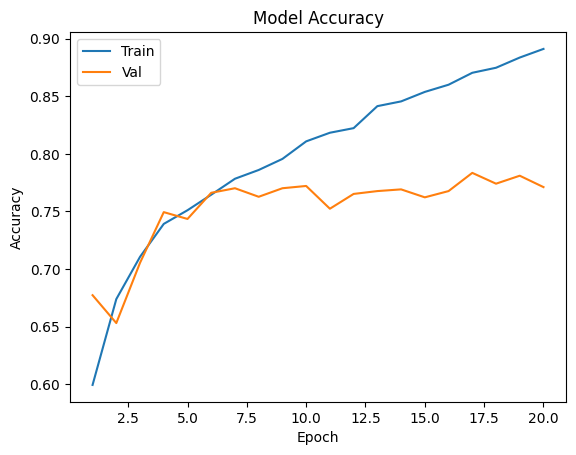

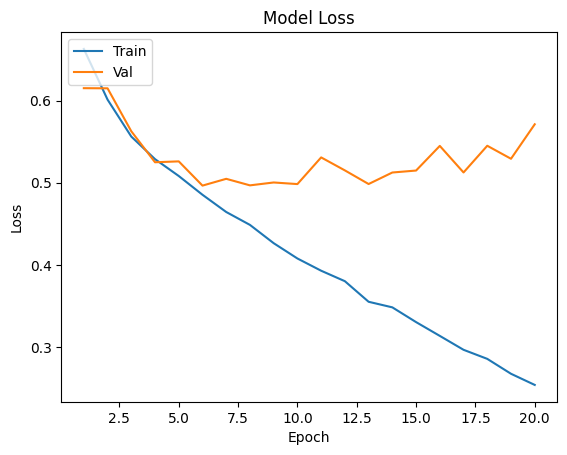

In [41]:
learning_curve(history, 20)